# Bagging and Random Forests Practice: Voter Data

## Setup

*Same setup as notebook 18 — run this cell to load and clean the data and define the preprocessing pipeline.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from plotnine import *

# Load raw data
voter_url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/non-voters/nonvoters_data.csv'
voter_raw = pd.read_csv(voter_url)

# Cleaning
voter_clean = voter_raw.drop(columns=['RespId', 'weight', 'Q1']).copy()

voter_clean['educ'] = pd.Categorical(voter_clean['educ'],
    categories=['High school or less', 'Some college', 'College'], ordered=True)
voter_clean['income_cat'] = pd.Categorical(voter_clean['income_cat'],
    categories=['Less than $40k', '$40-75k ', '$75-125k', '$125k or more'], ordered=True)
voter_clean['voter_category'] = pd.Categorical(voter_clean['voter_category'],
    categories=['rarely/never', 'sporadic', 'always'], ordered=False)

voter_clean = voter_clean[voter_clean['Q22'] != 5].copy()
voter_clean['Q22'] = voter_clean['Q22'].fillna('Not Asked').astype(str)

q28_cols = [f'Q28_{i}' for i in range(1, 9)]
for c in q28_cols:
    voter_clean[c] = voter_clean[c].replace(-1.0, 0).fillna('Not Asked').astype(str)

q29_cols = [f'Q29_{i}' for i in range(1, 11)]
for c in q29_cols:
    voter_clean[c] = voter_clean[c].replace(-1.0, 0).fillna('Not Asked').astype(str)

def _party_id(row):
    q31, q32, q33 = row['Q31'], row['Q32'], row['Q33']
    if   q31 == 1: return 'Strong Republican'
    elif q31 == 2: return 'Republican'
    elif q32 == 1: return 'Strong Democrat'
    elif q32 == 2: return 'Democrat'
    elif q33 == 1: return 'Lean Republican'
    elif q33 == 2: return 'Lean Democrat'
    else:          return 'Other'

voter_clean['Party_ID'] = voter_clean.apply(_party_id, axis=1)
party_order = ['Strong Republican', 'Republican', 'Lean Republican',
               'Other', 'Lean Democrat', 'Democrat', 'Strong Democrat']
voter_clean['Party_ID'] = pd.Categorical(voter_clean['Party_ID'],
                                         categories=party_order, ordered=True)
voter_clean = voter_clean.drop(columns=['Q31', 'Q32', 'Q33'])

for c in voter_clean.columns:
    if c != 'ppage' and voter_clean[c].dtype in ['float64', 'int64']:
        voter_clean[c] = voter_clean[c].replace(-1, np.nan)

# Train/test split
X_voter = voter_clean.drop(columns=['voter_category'])
y_voter = voter_clean['voter_category']

X_train, X_test, y_train, y_test = train_test_split(
    X_voter, y_voter,
    test_size=0.3,
    stratify=y_voter,
    random_state=4025
)

# Preprocessing pipeline
ordered_cat_cols = ['educ', 'income_cat', 'Party_ID']
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
nom_cols = [c for c in X_train.columns
            if c not in ordered_cat_cols and c not in num_cols]

preproc_voter = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median'))
    ]), num_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), ordered_cat_cols),
    ('nom', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), nom_cols),
], remainder='drop')

print(f"Training: {X_train.shape[0]} obs  |  Test: {X_test.shape[0]} obs")

Training: 4071 obs  |  Test: 1746 obs


/tmp/ipykernel_95067/1899812892.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.


## Bagging

### Fit the Bagging Model

We use `BaggingClassifier` wrapping an unpruned `DecisionTreeClassifier`. Setting `oob_score=True` gets us a free performance estimate without cross-validation.

In [3]:
bag_pipe = Pipeline([
    ('preproc', preproc_voter),
    ('bag', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=4025),
        n_estimators=500,
        oob_score=True,
        random_state=4025,
        n_jobs=-1
    ))
])

bag_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('bag', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### OOB Error and Test Accuracy

Compare OOB accuracy (free from the training process) to held-out test accuracy.

In [4]:
oob_acc = bag_pipe.named_steps['bag'].oob_score_
test_acc = accuracy_score(y_test, bag_pipe.predict(X_test))

print(f"OOB Accuracy:  {oob_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

OOB Accuracy:  0.650
Test Accuracy: 0.645


## Random Forests

### Tune `max_features`

`max_features` controls how many predictors are randomly considered at each split. We compare specific counts, `'sqrt'`, `'log2'`, and `None` (all features, equivalent to bagging). This may take a moment.

In [5]:
rf_pipe = Pipeline([
    ('preproc', preproc_voter),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=4025, n_jobs=-1))
])

param_grid_rf = {
    'rf__max_features': [1, 5, 10, 20, 'sqrt', 'log2', None]
}

rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4025)

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=rf_cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=4025))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_features': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

### CV Results

Plot CV accuracy across `max_features` values. The shaded band shows ± 1 standard deviation.

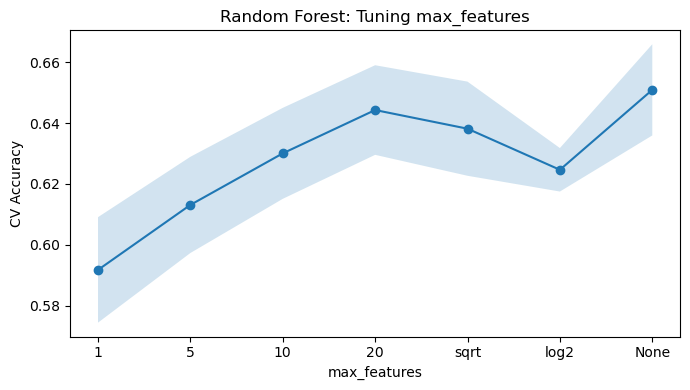

In [6]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(param_grid_rf['rf__max_features'])),
        rf_results['mean_test_score'], marker='o')
ax.fill_between(
    range(len(param_grid_rf['rf__max_features'])),
    rf_results['mean_test_score'] - rf_results['std_test_score'],
    rf_results['mean_test_score'] + rf_results['std_test_score'],
    alpha=0.2
)
ax.set_xticks(range(len(param_grid_rf['rf__max_features'])))
ax.set_xticklabels([str(v) for v in param_grid_rf['rf__max_features']])
ax.set_xlabel('max_features')
ax.set_ylabel('CV Accuracy')
ax.set_title('Random Forest: Tuning max_features')
plt.tight_layout()
plt.show()

### Best Parameters and Test Accuracy

In [ ]:
print("Best params:", rf_grid.best_params_)
print(f"Best CV Accuracy:  {rf_grid.best_score_:.3f}")
print(f"Test Accuracy:     {accuracy_score(y_test, rf_grid.predict(X_test)):.3f}")